In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

from torchvision import transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights

# =========================
# 1. Reproducibility
# =========================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =========================
# 2. Paths
# =========================
TRAIN_DIR = "/kaggle/input/datasets/jubayerhasan755/alzheimer-dataset02/alzheimer/train"
TEST_DIR  = "/kaggle/input/datasets/jubayerhasan755/alzheimer-dataset02/alzheimer/test"

# =========================
# 3. Set ratio for THIS notebook
# Change this in each notebook
# =========================
TRAIN_PERCENT = 70
TEST_PERCENT = 30

assert TRAIN_PERCENT + TEST_PERCENT == 100
print(f"Running ViT experiment for split: {TRAIN_PERCENT}:{TEST_PERCENT}")

# =========================
# 4. Collect image paths
# =========================
IMG_EXTENSIONS = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")

LABEL_MAP = {
    "AD": "AD",
    "MCI": "MCI",
    "CN": "CN"
}

def normalize_label(folder_name):
    return LABEL_MAP.get(folder_name, folder_name)

def collect_images_from_root(root_dir):
    rows = []
    class_folders = sorted([
        d for d in os.listdir(root_dir)
        if os.path.isdir(os.path.join(root_dir, d))
    ])

    for class_name in class_folders:
        class_path = os.path.join(root_dir, class_name)
        image_files = []

        for ext in IMG_EXTENSIONS:
            image_files.extend(glob.glob(os.path.join(class_path, ext)))

        normalized_label = normalize_label(class_name)

        for img_path in image_files:
            rows.append({
                "filepath": img_path,
                "label": normalized_label,
                "source_folder": os.path.basename(root_dir)
            })

    return pd.DataFrame(rows)

train_df = collect_images_from_root(TRAIN_DIR)
test_df  = collect_images_from_root(TEST_DIR)

full_df = pd.concat([train_df, test_df], ignore_index=True)
full_df = full_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Total images:", len(full_df))
print("\nClass distribution:")
print(full_df["label"].value_counts())
print("\nUnique labels:", full_df["label"].unique())

# =========================
# 5. Create split
# =========================
test_size = TEST_PERCENT / 100.0

train_val_df, test_split_df = train_test_split(
    full_df,
    test_size=test_size,
    stratify=full_df["label"],
    random_state=42
)

train_split_df, val_split_df = train_test_split(
    train_val_df,
    test_size=0.10,
    stratify=train_val_df["label"],
    random_state=42
)

print(f"\n===== Split {TRAIN_PERCENT}:{TEST_PERCENT} =====")
print(f"Train samples: {len(train_split_df)}")
print(train_split_df["label"].value_counts())

print(f"\nValidation samples: {len(val_split_df)}")
print(val_split_df["label"].value_counts())

print(f"\nTest samples: {len(test_split_df)}")
print(test_split_df["label"].value_counts())

# =========================
# 6. Save split CSVs
# =========================
OUTPUT_DIR = f"/kaggle/working/vit_split_{TRAIN_PERCENT}_{TEST_PERCENT}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_split_df.to_csv(os.path.join(OUTPUT_DIR, "train.csv"), index=False)
val_split_df.to_csv(os.path.join(OUTPUT_DIR, "val.csv"), index=False)
test_split_df.to_csv(os.path.join(OUTPUT_DIR, "test.csv"), index=False)

print("\nSplit CSV files saved to:", OUTPUT_DIR)

# =========================
# 7. Label mapping
# =========================
label_to_idx = {
    "AD": 0,
    "MCI": 1,
    "CN": 2
}

idx_to_label = {v: k for k, v in label_to_idx.items()}
print("\nLabel mapping:", label_to_idx)

# =========================
# 8. Dataset class
# =========================
class AlzheimerDataset(Dataset):
    def __init__(self, dataframe, transform=None, label_map=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_map = label_map

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = row["filepath"]
        label_name = row["label"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.label_map[label_name]
        return image, label

# =========================
# 9. Transforms
# =========================
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =========================
# 10. Datasets
# =========================
train_dataset = AlzheimerDataset(train_split_df, transform=train_transform, label_map=label_to_idx)
val_dataset   = AlzheimerDataset(val_split_df,   transform=val_test_transform, label_map=label_to_idx)
test_dataset  = AlzheimerDataset(test_split_df,  transform=val_test_transform, label_map=label_to_idx)

print("\nTrain samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

# =========================
# 11. DataLoaders
# =========================
BATCH_SIZE = 16
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("\nTrain batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

# =========================
# 12. Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing device:", device)

# =========================
# 13. Load pretrained ViT-B/16
# =========================
weights = ViT_B_16_Weights.DEFAULT
model = vit_b_16(weights=weights)

# Replace classifier head for 3 classes
in_features = model.heads.head.in_features
model.heads.head = nn.Linear(in_features, 3)

# Fine-tune full model
for param in model.parameters():
    param.requires_grad = True

model = model.to(device)
print("\nViT model ready.")

# =========================
# 14. Compute class weights
# =========================
class_counts = train_split_df["label"].value_counts()
print("\nTrain class counts:")
print(class_counts)

counts = np.array([
    class_counts["AD"],
    class_counts["MCI"],
    class_counts["CN"]
], dtype=np.float32)

class_weights = counts.sum() / (len(counts) * counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("\nClass weights:", class_weights)

# =========================
# 15. Loss and optimizer
# =========================
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("\nLoss and optimizer initialized.")

# =========================
# 16. Sanity check
# =========================
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("\nSanity Check:")
print("Input batch shape :", images.shape)
print("Label batch shape :", labels.shape)
print("Output batch shape:", outputs.shape)

Running ViT experiment for split: 70:30
Total images: 5154

Class distribution:
label
MCI    2590
CN     1440
AD     1124
Name: count, dtype: int64

Unique labels: ['CN' 'AD' 'MCI']

===== Split 70:30 =====
Train samples: 3246
label
MCI    1631
CN      907
AD      708
Name: count, dtype: int64

Validation samples: 361
label
MCI    181
CN     101
AD      79
Name: count, dtype: int64

Test samples: 1547
label
MCI    778
CN     432
AD     337
Name: count, dtype: int64

Split CSV files saved to: /kaggle/working/vit_split_70_30

Label mapping: {'AD': 0, 'MCI': 1, 'CN': 2}

Train samples: 3246
Val samples: 361
Test samples: 1547

Train batches: 203
Val batches: 23
Test batches: 97

Using device: cuda
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 192MB/s]  



ViT model ready.

Train class counts:
label
MCI    1631
CN      907
AD      708
Name: count, dtype: int64

Class weights: tensor([1.5282, 0.6634, 1.1929], device='cuda:0')

Loss and optimizer initialized.

Sanity Check:
Input batch shape : torch.Size([16, 3, 224, 224])
Label batch shape : torch.Size([16])
Output batch shape: torch.Size([16, 3])


Results will be saved to: /kaggle/working/vit_results_70_30
Epoch [1/50] | Train Loss: 1.1223 | Train Acc: 0.3592 | Val Loss: 1.0724 | Val Acc: 0.5402 | Time: 117.32s
 Best model saved at epoch 1 with val_acc=0.5402
Epoch [2/50] | Train Loss: 1.0593 | Train Acc: 0.4295 | Val Loss: 1.0005 | Val Acc: 0.5125 | Time: 131.28s
Epoch [3/50] | Train Loss: 0.9895 | Train Acc: 0.4920 | Val Loss: 0.9288 | Val Acc: 0.4875 | Time: 135.27s
Epoch [4/50] | Train Loss: 0.9124 | Train Acc: 0.5653 | Val Loss: 0.8396 | Val Acc: 0.5540 | Time: 135.46s
 Best model saved at epoch 4 with val_acc=0.5540
Epoch [5/50] | Train Loss: 0.7755 | Train Acc: 0.6470 | Val Loss: 0.7765 | Val Acc: 0.7036 | Time: 135.89s
 Best model saved at epoch 5 with val_acc=0.7036
Epoch [6/50] | Train Loss: 0.6638 | Train Acc: 0.6996 | Val Loss: 0.6000 | Val Acc: 0.7673 | Time: 135.39s
 Best model saved at epoch 6 with val_acc=0.7673
Epoch [7/50] | Train Loss: 0.5553 | Train Acc: 0.7745 | Val Loss: 0.5814 | Val Acc: 0.7036 | Time: 135

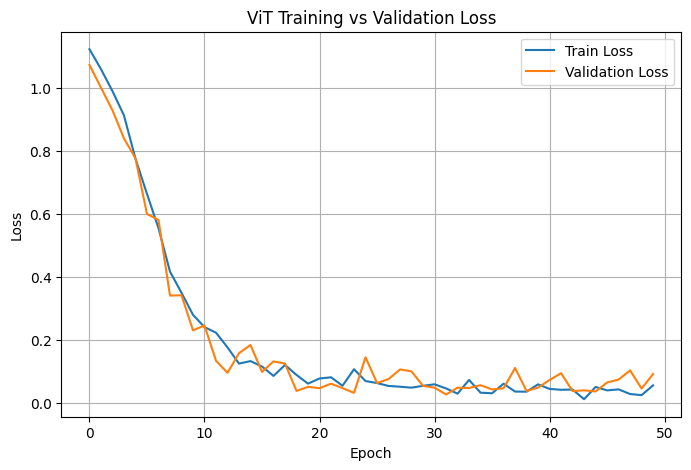

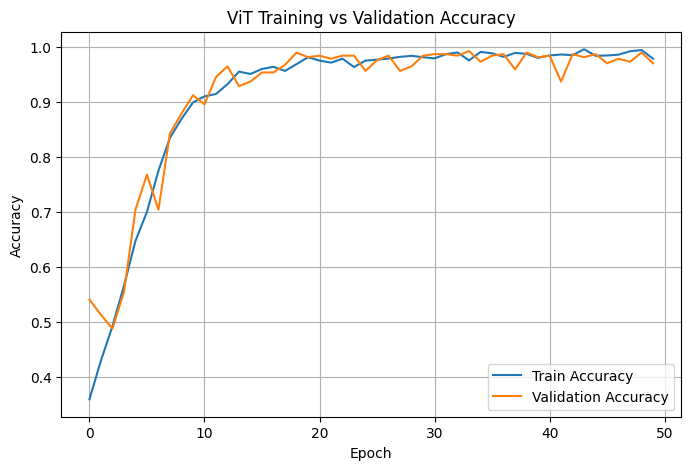


Step 2 complete: ViT training finished successfully.


In [2]:
# =========================
# ViT Step 2: Training + validation + best model saving
# =========================

import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import torch

# =========================
# 1. Training settings
# =========================
NUM_EPOCHS = 50
PATIENCE = 50   # keeps training through all 50 epochs
SAVE_DIR = f"/kaggle/working/vit_results_{TRAIN_PERCENT}_{TEST_PERCENT}"
os.makedirs(SAVE_DIR, exist_ok=True)

best_model_path = os.path.join(SAVE_DIR, "best_vit_b16.pth")

print("Results will be saved to:", SAVE_DIR)

# =========================
# 2. Helper functions
# =========================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_correct / total_samples

    return epoch_loss, epoch_acc


def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            running_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_correct / total_samples

    return epoch_loss, epoch_acc

# =========================
# 3. History containers
# =========================
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_acc = 0.0
best_epoch = 0
epochs_without_improvement = 0

# =========================
# 4. Training loop
# =========================
start_training_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    epoch_time = time.time() - epoch_start_time

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Time: {epoch_time:.2f}s")

    # Save best model based on validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        epochs_without_improvement = 0

        torch.save(model.state_dict(), best_model_path)
        print(f" Best model saved at epoch {best_epoch} with val_acc={best_val_acc:.4f}")
    else:
        epochs_without_improvement += 1

    # Early stopping check
    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping triggered after {epoch+1} epochs.")
        break

total_training_time = time.time() - start_training_time

print("\nTraining complete.")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Best Epoch: {best_epoch}")
print(f"Total Training Time: {total_training_time:.2f} seconds")
print(f"Best model saved to: {best_model_path}")

# =========================
# 5. Load best model
# =========================
model.load_state_dict(torch.load(best_model_path))
model = model.to(device)
model.eval()

print("Best ViT model loaded for final evaluation.")

# =========================
# 6. Save training history
# =========================
history_df = pd.DataFrame({
    "epoch": list(range(1, len(history["train_loss"]) + 1)),
    "train_loss": history["train_loss"],
    "val_loss": history["val_loss"],
    "train_acc": history["train_acc"],
    "val_acc": history["val_acc"]
})

history_csv_path = os.path.join(SAVE_DIR, "training_history.csv")
history_df.to_csv(history_csv_path, index=False)

print("Training history saved to:", history_csv_path)

# =========================
# 7. Plot and save loss curve
# =========================
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ViT Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "loss_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 8. Plot and save accuracy curve
# =========================
plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ViT Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "accuracy_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

print("\nStep 2 complete: ViT training finished successfully.")

Total Testing Time: 20.38 seconds
Labels shape: (1547,)
Preds shape: (1547,)
Probs shape: (1547, 3)

Overall Test Accuracy: 0.9800

Per-Class Accuracy:
AD: 0.9792
MCI: 0.9794
CN: 0.9815

Macro Metrics:
Precision (Macro): 0.9743
Recall (Macro):    0.9800
F1-score (Macro):  0.9771

Weighted Metrics:
Precision (Weighted): 0.9803
Recall (Weighted):    0.9800
F1-score (Weighted):  0.9800

Classification Report:

              precision    recall  f1-score   support

          AD     0.9649    0.9792    0.9720       337
         MCI     0.9987    0.9794    0.9890       778
          CN     0.9593    0.9815    0.9703       432

    accuracy                         0.9800      1547
   macro avg     0.9743    0.9800    0.9771      1547
weighted avg     0.9803    0.9800    0.9800      1547

Classification report saved to: /kaggle/working/vit_results_70_30/classification_report.csv


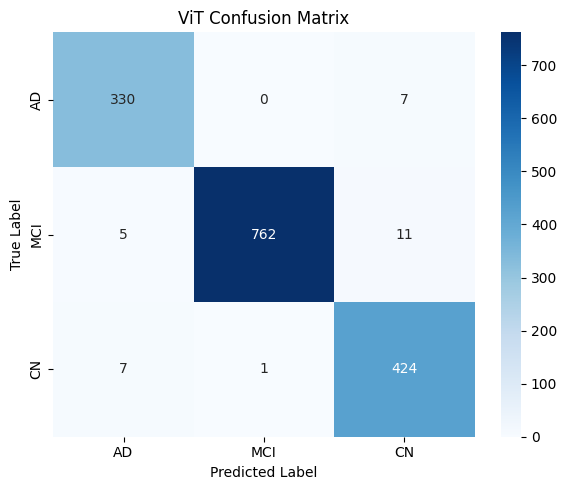

Confusion matrix values saved to: /kaggle/working/vit_results_70_30/confusion_matrix_values.csv

Per-Class ROC-AUC:
AD: 0.9979
MCI: 0.9987
CN: 0.9961

Macro ROC-AUC:    0.9976
Weighted ROC-AUC: 0.9978


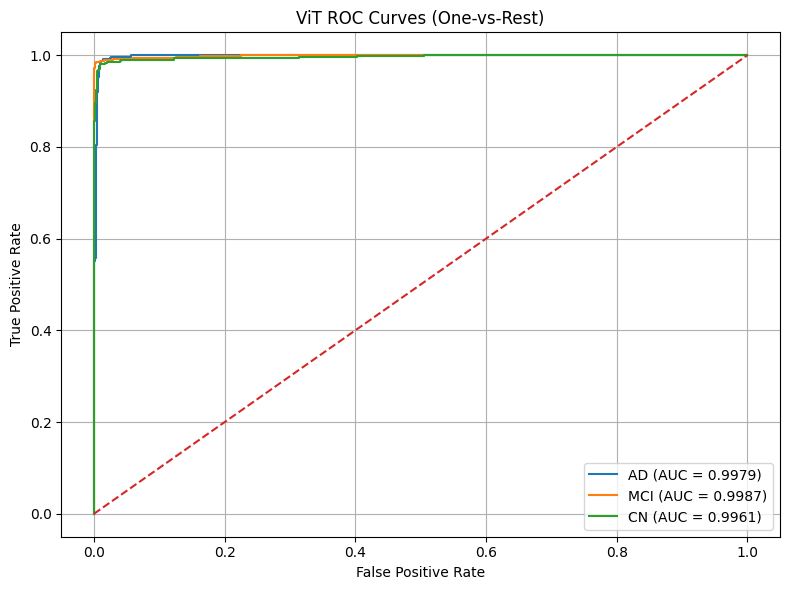

Final results saved to: /kaggle/working/vit_results_70_30/final_results.csv


,Model,Train_Test_Split,Input_Size,Overall_Accuracy,AD_Accuracy,MCI_Accuracy,CN_Accuracy,Precision_Macro,Recall_Macro,F1_Macro,...,F1_Weighted,AD_ROC_AUC,MCI_ROC_AUC,CN_ROC_AUC,Macro_ROC_AUC,Weighted_ROC_AUC,Training_Time_sec,Testing_Time_sec,Best_Val_Accuracy,Best_Epoch
0,ViT-B16,70:30,224x224,0.979961,0.979228,0.979434,0.981481,0.974293,0.980048,0.977079,...,0.980049,0.997925,0.998736,0.996134,0.997599,0.997833,6786.032944,20.375935,0.99169,34


Failure modes saved to: /kaggle/working/vit_results_70_30/failure_modes.csv


,True_Class,Predicted_As,Count
0,MCI,CN,11
1,AD,CN,7
2,CN,AD,7
3,MCI,AD,5
4,CN,MCI,1
5,AD,MCI,0



ViT Step 3 complete: Final evaluation finished successfully.


In [3]:
# =========================
# ViT Step 3: Final test evaluation
# =========================

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# =========================
# 1. Run inference on test set
# =========================
model.eval()

all_labels = []
all_preds = []
all_probs = []

start_test_time = time.time()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

total_test_time = time.time() - start_test_time

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

print(f"Total Testing Time: {total_test_time:.2f} seconds")
print("Labels shape:", all_labels.shape)
print("Preds shape:", all_preds.shape)
print("Probs shape:", all_probs.shape)

# =========================
# 2. Overall Accuracy
# =========================
overall_accuracy = accuracy_score(all_labels, all_preds)
print(f"\nOverall Test Accuracy: {overall_accuracy:.4f}")

# =========================
# 3. Confusion Matrix + Per-Class Accuracy
# =========================
class_names = ["AD", "MCI", "CN"]

cm = confusion_matrix(all_labels, all_preds)
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

print("\nPer-Class Accuracy:")
for i, class_name in enumerate(class_names):
    print(f"{class_name}: {per_class_accuracy[i]:.4f}")

# =========================
# 4. Precision / Recall / F1
# =========================
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="macro", zero_division=0
)

precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="weighted", zero_division=0
)

print("\nMacro Metrics:")
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro):    {recall_macro:.4f}")
print(f"F1-score (Macro):  {f1_macro:.4f}")

print("\nWeighted Metrics:")
print(f"Precision (Weighted): {precision_weighted:.4f}")
print(f"Recall (Weighted):    {recall_weighted:.4f}")
print(f"F1-score (Weighted):  {f1_weighted:.4f}")

# =========================
# 5. Full Classification Report
# =========================
report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("\nClassification Report:\n")
print(report)

# Save classification report as CSV
report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
report_csv_path = os.path.join(SAVE_DIR, "classification_report.csv")
report_df.to_csv(report_csv_path, index=True)

print("Classification report saved to:", report_csv_path)

# =========================
# 6. Plot Confusion Matrix
# =========================
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ViT Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

# Save confusion matrix values
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_csv_path = os.path.join(SAVE_DIR, "confusion_matrix_values.csv")
cm_df.to_csv(cm_csv_path)

print("Confusion matrix values saved to:", cm_csv_path)

# =========================
# 7. Multiclass ROC-AUC
# =========================
all_labels_bin = label_binarize(all_labels, classes=[0, 1, 2])

roc_auc_per_class = {}
fpr = {}
tpr = {}
roc_auc_curves = {}

for i, class_name in enumerate(class_names):
    fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc_curves[i] = auc(fpr[i], tpr[i])
    roc_auc_per_class[class_name] = roc_auc_curves[i]

macro_roc_auc = roc_auc_score(
    all_labels_bin,
    all_probs,
    average="macro",
    multi_class="ovr"
)

weighted_roc_auc = roc_auc_score(
    all_labels_bin,
    all_probs,
    average="weighted",
    multi_class="ovr"
)

print("\nPer-Class ROC-AUC:")
for class_name, score in roc_auc_per_class.items():
    print(f"{class_name}: {score:.4f}")

print(f"\nMacro ROC-AUC:    {macro_roc_auc:.4f}")
print(f"Weighted ROC-AUC: {weighted_roc_auc:.4f}")

# =========================
# 8. Plot ROC Curves
# =========================
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], label=f"{class_name} (AUC = {roc_auc_curves[i]:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ViT ROC Curves (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "roc_curves.png"), dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 9. Save final metrics table
# =========================
results_dict = {
    "Model": "ViT-B16",
    "Train_Test_Split": f"{TRAIN_PERCENT}:{TEST_PERCENT}",
    "Input_Size": f"{IMG_SIZE}x{IMG_SIZE}",

    "Overall_Accuracy": overall_accuracy,

    "AD_Accuracy": per_class_accuracy[0],
    "MCI_Accuracy": per_class_accuracy[1],
    "CN_Accuracy": per_class_accuracy[2],

    "Precision_Macro": precision_macro,
    "Recall_Macro": recall_macro,
    "F1_Macro": f1_macro,

    "Precision_Weighted": precision_weighted,
    "Recall_Weighted": recall_weighted,
    "F1_Weighted": f1_weighted,

    "AD_ROC_AUC": roc_auc_per_class["AD"],
    "MCI_ROC_AUC": roc_auc_per_class["MCI"],
    "CN_ROC_AUC": roc_auc_per_class["CN"],

    "Macro_ROC_AUC": macro_roc_auc,
    "Weighted_ROC_AUC": weighted_roc_auc,

    "Training_Time_sec": total_training_time,
    "Testing_Time_sec": total_test_time,
    "Best_Val_Accuracy": best_val_acc,
    "Best_Epoch": best_epoch
}

results_df = pd.DataFrame([results_dict])

results_csv_path = os.path.join(SAVE_DIR, "final_results.csv")
results_df.to_csv(results_csv_path, index=False)

print("Final results saved to:", results_csv_path)
display(results_df)

# =========================
# 10. Failure modes
# =========================
failure_modes = []

for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j:
            failure_modes.append({
                "True_Class": class_names[i],
                "Predicted_As": class_names[j],
                "Count": cm[i, j]
            })

failure_modes_df = pd.DataFrame(failure_modes)
failure_modes_df = failure_modes_df.sort_values(by="Count", ascending=False).reset_index(drop=True)

failure_modes_path = os.path.join(SAVE_DIR, "failure_modes.csv")
failure_modes_df.to_csv(failure_modes_path, index=False)

print("Failure modes saved to:", failure_modes_path)
display(failure_modes_df.head(10))

print("\nViT Step 3 complete: Final evaluation finished successfully.")